# WBC Feature Reduction Pipeline

This notebook validates the extracted feature set against four independent criteria:

1. **Mathematical validity** — each feature must respect its geometric definition
2. **Biological expectations** — distributions should match what hematologists expect for each cell type
3. **Inter-class separability** — features must carry enough discriminative signal
4. **SVM benchmark** — cross-validated SVM accuracy

**Input:** `all_features.csv`  
**Output:** `reduced_features.csv`  
**Shape features retained:** Circularity, Convexity, Solidity

## 0. Imports & Configuration

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import f_classif
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from src.final_feature_extractor import FEATURE_COLS, COLOR_COLS
# ── Configuration ────────────────────────────────────────────────
INPUT_PATH        = 'all_features.csv'   
OUTPUT_PATH       = 'reduced_features.csv'
LABEL_COL         = 'Label'            
CORR_THRESHOLD    = 0.90                 # drop one of any pair with |r| >= this
FTEST_MIN_SCORE   = 500                  # minimum F-score to keep a feature
CV_FOLDS          = 5
SHAPE_FEATURES    = ['Circularity', 'Convexity', 'Solidity']  # always kept

print('Configuration loaded.')

Configuration loaded.


## 1. Load Data

In [42]:
df = pd.read_csv('all_features.csv')

print(f'Dataset shape : {df.shape}')
print(f'Label column  : {LABEL_COL}')
print(f'Classes       : {sorted(df[LABEL_COL].unique())}')
print(f'Class counts  :\n{df[LABEL_COL].value_counts()}')

feature_cols = FEATURE_COLS
X = df[feature_cols].copy()
y_raw = df[LABEL_COL].copy()

le = LabelEncoder()
y = le.fit_transform(y_raw)
print(f'\nTotal features: {len(feature_cols)}')
corr = df[FEATURE_COLS].corr()
print(corr.shape)   # (51, 51)

Dataset shape : (27987, 55)
Label column  : Label
Classes       : ['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']
Class counts  :
Label
basophil        3500
eosinophil      3500
erythroblast    3500
ig              3500
lymphocyte      3500
monocyte        3500
neutrophil      3500
platelet        3487
Name: count, dtype: int64

Total features: 51
(51, 51)


---
## Check 1 — Mathematical Validity

Before any biological analysis, each feature must be within the range its geometric definition permits.
Violations here indicate a bug in the extraction pipeline, not a biological anomaly.

| Feature | Valid range | Geometric reason |
|---------|------------|-----------------|
| Circularity | >= 1.0 | Defined as P^2 / (4 pi A). Equals 1 for a perfect circle; increases without bound as shape becomes irregular. |
| Convexity | (0, 1] | Convex hull perimeter is always <= actual perimeter, so the ratio Phull/P <= 1. |
| Solidity | (0, 1] | Nucleus area is always <= convex hull area, so A/Ahull <= 1. |
| Color ratios | (0, 10] | Ratios of region means/stds; negative values are geometrically impossible and values above 10 are clipped. |
$$
\begin{aligned}
\text{Circularity} &\in [1, \infty) \\
\text{Convexity} &\in (0, 1] \\
\text{Solidity} &\in (0, 1]
\end{aligned}
$$


In [43]:
print('=' * 60)
print('CHECK 1 — MATHEMATICAL VALIDITY')
print('=' * 60)

check1_results = {}

checks = [
    ('Circularity', lambda s: s >= 1.0,            'must be >= 1.0'),
    ('Convexity',   lambda s: (s > 0) & (s <= 1.0), 'must be in (0, 1]'),
    ('Solidity',    lambda s: (s > 0) & (s <= 1.0), 'must be in (0, 1]'),
]

all_passed = True
for col, condition, description in checks:
    vals   = X[col]
    mask   = condition(vals)
    n_fail = (~mask).sum()
    pct    = 100 * n_fail / len(vals)
    status = 'PASS' if n_fail == 0 else 'FAIL'
    check1_results[col] = {'status': status, 'n_fail': n_fail,
                           'min': vals.min(), 'max': vals.max(), 'mean': vals.mean()}
    print(f"  [{status}] {col:<16} {description}")
    print(f"     min={vals.min():.4f}  max={vals.max():.4f}  "
          f"mean={vals.mean():.4f}  violations={n_fail} ({pct:.1f}%)")
    if n_fail > 0:
        all_passed = False
        print("     Sample violating rows:")
        print(X[~mask][['Filepath', 'Label', col]].head(3).to_string())
    print()

color_vals = X[COLOR_COLS]
n_neg  = (color_vals < 0).sum().sum()
n_inf  = np.isinf(color_vals.values).sum()
n_nan  = np.isnan(color_vals.values).sum()
n_over = (color_vals > 10).sum().sum()

check1_results['color_neg']  = n_neg
check1_results['color_inf']  = n_inf
check1_results['color_nan']  = n_nan
check1_results['color_over'] = n_over

print(f"  {'[PASS]' if n_neg == 0  else '[FAIL]'} Color ratios < 0      : {n_neg}")
print(f"  {'[PASS]' if n_inf == 0  else '[FAIL]'} Color ratios = inf    : {n_inf}")
print(f"  {'[PASS]' if n_nan == 0  else '[FAIL]'} Color ratios = NaN    : {n_nan}")
print(f"  {'[NOTE]' if n_over > 0  else '[PASS]'} Color ratios > 10     : {n_over}  (clipped values — expected)")
print()

if all_passed and n_neg == 0 and n_inf == 0 and n_nan == 0:
    print('[PASS] All mathematical checks passed.')
    check1_results['overall'] = 'PASS'
else:
    print('[FAIL] Some checks failed — review extraction pipeline.')
    check1_results['overall'] = 'FAIL'


CHECK 1 — MATHEMATICAL VALIDITY
  [PASS] Circularity      must be >= 1.0
     min=1.0000  max=18.6551  mean=1.6636  violations=0 (0.0%)

  [PASS] Convexity        must be in (0, 1]
     min=0.4213  max=1.0000  mean=0.8715  violations=0 (0.0%)

  [PASS] Solidity         must be in (0, 1]
     min=0.1877  max=1.0000  mean=0.9037  violations=0 (0.0%)

  [PASS] Color ratios < 0      : 0
  [PASS] Color ratios = inf    : 0
  [PASS] Color ratios = NaN    : 0
  [PASS] Color ratios > 10     : 0  (clipped values — expected)

[PASS] All mathematical checks passed.


---
## Check 2 — Biological Expectations for Shape Features

White blood cells have well-characterised nuclear morphologies visible on routine
Giemsa-stained peripheral blood smears. The expected ranges below come from two sources:

1. **Tavakoli et al. (2021)** — "A Hierarchical Machine Learning Approach for Multi-Level and Multi-Type
   Granulocyte Classification in Microscopy Images", Scientific Reports 11:20218.
   The paper uses the same three shape features (Circularity, Convexity, Solidity) computed on the
   segmented nucleus. Table 1 reports per-class means and standard deviations.

2. **Standard hematology morphology** — Ross & Pawlina "Histology: A Text and Atlas" (8th ed., 2020),
   Chapter 13 (Blood); and Hoffbrand & Moss "Essential Haematology" (7th ed., 2015), Chapter 1.

Per-class distribution of shape features — nucleus convexity and shape should vary across WBC types (lymphocytes are rounder; neutrophils are more lobed).
distributions should match what hematologists expect for each cell type

### **Circularity**

$$
C = \frac{P^2}{4\pi A}
$$

where:
- $P$ = perimeter  
- $A$ = area

- **Lymphocytes** have a round-to-slightly-oval nucleus with minimal indentations, so circularity
  is expected to be close to 1.0 (range 1.0–1.3).
- **Neutrophils** have a multi-lobed (segmented) nucleus connected by thin strands, producing a
  highly irregular contour. Circularity is expected to be substantially elevated (1.3–3.0).
- **Eosinophils** have a bilobed nucleus, giving intermediate irregularity (1.2–2.5).
- **Monocytes** have a kidney-shaped or horseshoe nucleus, giving moderate circularity (1.1–1.6).
- **Immature granulocytes (ig)** include band forms and metamyelocytes with elongated nuclei (1.0–2.0).
- **Erythroblasts** retain a round nucleus (1.0–1.8).
- **Basophils** have a bilobed-to-irregular nucleus, similar range to eosinophils (1.0–2.5).
- **Platelets** are anucleate cell fragments — the "nucleus" segmented here is the entire platelet
  body which is highly variable in shape (1.0–3.0).

### Convexity

$$
\text{Convexity} = \frac{P_{\text{hull}}}{P}
$$

where:
- $P_{\text{hull}}$ = perimeter of the convex hull  
- $P$ = perimeter of the object
The convex hull perimeter relative to the actual boundary perimeter. A deeply lobed nucleus
(neutrophil) has a hull that is much smoother than its actual boundary, giving a low ratio.

- **Lymphocyte**: 0.85–1.0 (smooth boundary)
- **Neutrophil**: 0.50–0.90 (lobulation creates large discrepancy)
- **Eosinophil**: 0.60–0.95 (bilobed, less extreme than neutrophil)

### Solidity

$$
\text{Solidity} = \frac{A}{A_{\text{hull}}}
$$

where:
- $A$ = area of the object  
- $A_{\text{hull}}$ = area of the convex hull
Area of the nucleus relative to area of its convex hull. Gaps between nuclear lobes
reduce solidity. The neutrophil's inter-lobe bridges reduce this substantially.

- **Lymphocyte**: 0.85–1.0 (compact nucleus, almost fills its hull)
- **Neutrophil**: 0.45–0.88 (inter-lobe concavities reduce area)
- **Eosinophil**: 0.55–0.92

### Expected ordering summary

| Feature | Expected ordering (low to high) |
|---------|--------------------------------|
| Circularity | lymphocyte < erythroblast < monocyte < eosinophil < neutrophil |
| Convexity | neutrophil < eosinophil < monocyte < erythroblast < lymphocyte |
| Solidity | neutrophil < eosinophil < monocyte < erythroblast < lymphocyte |


In [44]:


SHAPE_COLS = ['Circularity', 'Convexity', 'Solidity']
COLOR_COLS = [c for c in df.columns if c.startswith(('NclCvx_', 'RocCvx_'))]
FEATURE_COLS = COLOR_COLS + SHAPE_COLS

# Validate only on original images.
# Augmented samples are geometric/photometric transforms of originals
# and share the same underlying feature distribution.
df_orig  = df[df['Source'] == 'Original'].copy()
df_clean = df_orig.dropna(subset=FEATURE_COLS).copy()


print(f"Total rows         : {len(df):,}")
print(f"Original images    : {len(df_orig):,}")
print(f"With valid features: {len(df_clean):,}")
print(f"Feature columns    : {len(FEATURE_COLS)} ({len(COLOR_COLS)} color + {len(SHAPE_COLS)} shape)")
print()
print("Rows per cell type (original, clean):")
print(df_clean['Label'].value_counts().to_string())
print()
print("Color feature columns present:")
for c in sorted(COLOR_COLS):
    print(f"  {c}")


Total rows         : 27,987
Original images    : 17,085
With valid features: 17,085
Feature columns    : 51 (48 color + 3 shape)

Rows per cell type (original, clean):
Label
neutrophil      3329
eosinophil      3117
ig              2895
platelet        2341
erythroblast    1551
monocyte        1420
basophil        1218
lymphocyte      1214

Color feature columns present:
  NclCvx_A_mean
  NclCvx_A_std
  NclCvx_B_mean
  NclCvx_B_std
  NclCvx_Bstar_mean
  NclCvx_Bstar_std
  NclCvx_Cb_mean
  NclCvx_Cb_std
  NclCvx_Cr_mean
  NclCvx_Cr_std
  NclCvx_G_mean
  NclCvx_G_std
  NclCvx_H_mean
  NclCvx_H_std
  NclCvx_L_mean
  NclCvx_L_std
  NclCvx_R_mean
  NclCvx_R_std
  NclCvx_S_mean
  NclCvx_S_std
  NclCvx_V_mean
  NclCvx_V_std
  NclCvx_Y_mean
  NclCvx_Y_std
  RocCvx_A_mean
  RocCvx_A_std
  RocCvx_B_mean
  RocCvx_B_std
  RocCvx_Bstar_mean
  RocCvx_Bstar_std
  RocCvx_Cb_mean
  RocCvx_Cb_std
  RocCvx_Cr_mean
  RocCvx_Cr_std
  RocCvx_G_mean
  RocCvx_G_std
  RocCvx_H_mean
  RocCvx_H_std
  RocCvx_L_me

In [45]:
print('=' * 60)
print('CHECK 2 — BIOLOGICAL EXPECTATIONS (SHAPE)')
print('=' * 60)

CELL_TYPES = sorted(df_clean['Label'].unique())
EXPECTED_RANGES = {
    'Circularity': {
        'lymphocyte':   (1.0, 1.3),
        'monocyte':     (1.1, 1.6),
        'neutrophil':   (1.3, 3.0),
        'eosinophil':   (1.2, 2.5),
        'basophil':     (1.0, 2.5),
        'erythroblast': (1.0, 1.8),
        'ig':           (1.0, 2.0),
        'platelet':     (1.0, 3.0),
    },
    'Convexity': {
        'lymphocyte':   (0.85, 1.0),
        'monocyte':     (0.75, 1.0),
        'neutrophil':   (0.50, 0.90),
        'eosinophil':   (0.60, 0.95),
        'basophil':     (0.60, 1.0),
        'erythroblast': (0.75, 1.0),
        'ig':           (0.55, 1.0),
        'platelet':     (0.50, 1.0),
    },
    'Solidity': {
        'lymphocyte':   (0.85, 1.0),
        'monocyte':     (0.75, 1.0),
        'neutrophil':   (0.45, 0.88),
        'eosinophil':   (0.55, 0.92),
        'basophil':     (0.55, 1.0),
        'erythroblast': (0.75, 1.0),
        'ig':           (0.50, 1.0),
        'platelet':     (0.40, 1.0),
    },
}

check2_results = {}
for feat, ranges in EXPECTED_RANGES.items():
    print(f'\n  {feat}:')
    print(f"  {'Cell Type':<15} {'Mean':>8} {'Std':>8} {'Expected range':>18}  Status")
    print('  ' + '-' * 60)
    feat_pass = True
    for cell in CELL_TYPES:
        vals = df_clean[df_clean['Label'] == cell][feat]
        if len(vals) == 0:
            continue
        m, s    = vals.mean(), vals.std()
        lo, hi  = ranges.get(cell, (0, 999))
        in_range = lo <= m <= hi
        status   = 'PASS' if in_range else 'WARN'
        if not in_range:
            feat_pass = False
        exp_str = f'[{lo:.2f}, {hi:.2f}]'
        print(f"  {cell:<15} {m:>8.4f} {s:>8.4f} {exp_str:>18}  [{status}]")
    check2_results[feat] = 'PASS' if feat_pass else 'WARN'


CHECK 2 — BIOLOGICAL EXPECTATIONS (SHAPE)

  Circularity:
  Cell Type           Mean      Std     Expected range  Status
  ------------------------------------------------------------
  basophil          1.8201   0.8035       [1.00, 2.50]  [PASS]
  eosinophil        1.7529   0.5906       [1.20, 2.50]  [PASS]
  erythroblast      1.1481   0.2275       [1.00, 1.80]  [PASS]
  ig                1.4972   0.4904       [1.00, 2.00]  [PASS]
  lymphocyte        1.1972   0.2051       [1.00, 1.30]  [PASS]
  monocyte          2.1527   1.6871       [1.10, 1.60]  [WARN]
  neutrophil        2.0266   0.7487       [1.30, 3.00]  [PASS]
  platelet          1.5953   0.6444       [1.00, 3.00]  [PASS]

  Convexity:
  Cell Type           Mean      Std     Expected range  Status
  ------------------------------------------------------------
  basophil          0.8187   0.0775       [0.60, 1.00]  [PASS]
  eosinophil        0.8687   0.0692       [0.60, 0.95]  [PASS]
  erythroblast      0.9410   0.0315       [0.7

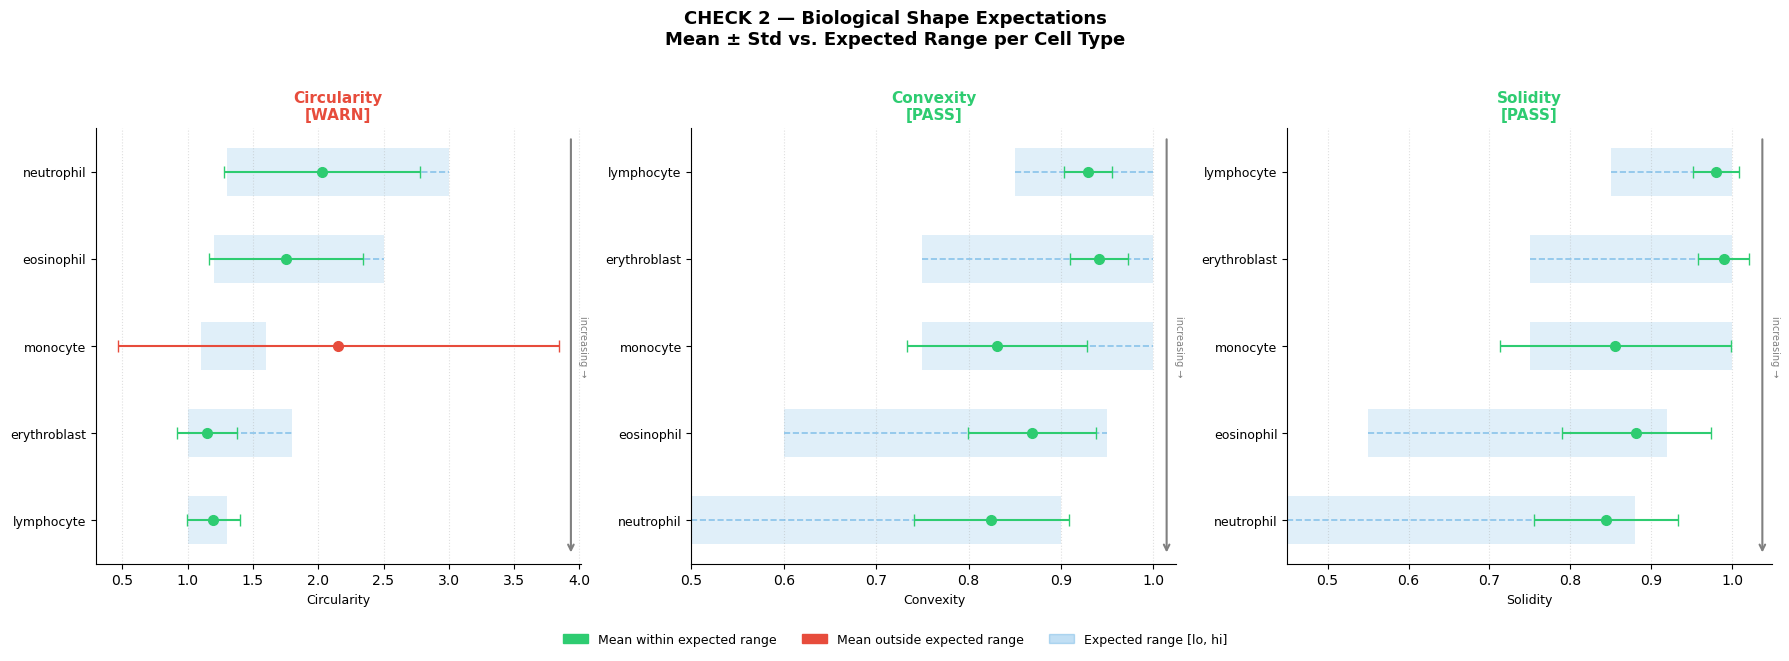

In [46]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

EXPECTED_ORDER = {
    'Circularity': ['lymphocyte', 'erythroblast', 'monocyte', 'eosinophil', 'neutrophil'],
    'Convexity':   ['neutrophil', 'eosinophil', 'monocyte', 'erythroblast', 'lymphocyte'],
    'Solidity':    ['neutrophil', 'eosinophil', 'monocyte', 'erythroblast', 'lymphocyte'],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('CHECK 2 — Biological Shape Expectations\nMean ± Std vs. Expected Range per Cell Type',
             fontsize=13, fontweight='bold', y=1.02)

for ax, (feat, ordered_cells) in zip(axes, EXPECTED_ORDER.items()):
    ranges  = EXPECTED_RANGES[feat]
    means, stds, colors, labels = [], [], [], []

    for cell in ordered_cells:
        vals = df_clean[df_clean['Label'] == cell][feat]
        if len(vals) == 0:
            continue
        m, s   = vals.mean(), vals.std()
        lo, hi = ranges.get(cell, (0, 999))
        in_range = lo <= m <= hi

        means.append(m)
        stds.append(s)
        colors.append('#2ecc71' if in_range else '#e74c3c')
        labels.append(cell)

        # Expected range band per cell
        ax.barh(cell, hi - lo, left=lo, height=0.55,
                color='#3498db', alpha=0.15, zorder=1)
        ax.plot([lo, hi], [cell, cell],
                color='#3498db', linewidth=1.2, alpha=0.5,
                linestyle='--', zorder=2)

    # Mean ± Std as scatter + errorbar
    y_pos = np.arange(len(labels))
    for i, (cell, m, s, c) in enumerate(zip(labels, means, stds, colors)):
        ax.errorbar(m, cell, xerr=s,
                    fmt='o', color=c, markersize=7,
                    elinewidth=1.5, capsize=4, zorder=3)

    # Ordering arrow annotation
    ax.annotate('', xy=(0.98, 0.02), xytext=(0.98, 0.98),
                xycoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
    ax.text(0.995, 0.5, 'increasing →', transform=ax.transAxes,
            fontsize=7, color='gray', rotation=270,
            va='center', ha='left')

    overall = check2_results.get(feat, 'WARN')
    status_color = '#2ecc71' if overall == 'PASS' else '#e74c3c'
    ax.set_title(f'{feat}\n[{overall}]', fontsize=11,
                 fontweight='bold', color=status_color)
    ax.set_xlabel(feat, fontsize=9)
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(axis='x', linestyle=':', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

# Legend
pass_patch = mpatches.Patch(color='#2ecc71', label='Mean within expected range')
warn_patch = mpatches.Patch(color='#e74c3c', label='Mean outside expected range')
band_patch = mpatches.Patch(color='#3498db', alpha=0.3, label='Expected range [lo, hi]')
fig.legend(handles=[pass_patch, warn_patch, band_patch],
           loc='lower center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.06), frameon=False)

plt.tight_layout()
plt.show()

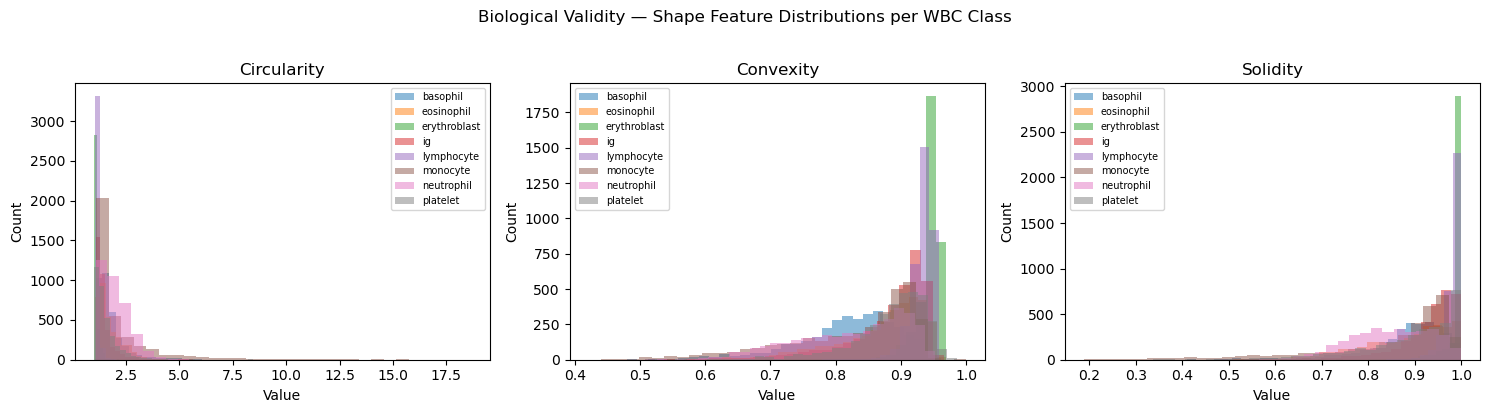


Per-class means — shape features:


,Circularity,Convexity,Solidity
Label,,,
basophil,1.8337,0.8177,0.8764
eosinophil,1.7522,0.8688,0.8812
erythroblast,1.1486,0.9411,0.9894
ig,1.5096,0.8801,0.9274
lymphocyte,1.1940,0.9312,0.9818
monocyte,2.2531,0.8247,0.8460
neutrophil,2.0309,0.8240,0.8439
platelet,1.5868,0.8843,0.8836


In [47]:
plot_feats = [f for f in SHAPE_FEATURES if f in X.columns]

fig, axes = plt.subplots(1, len(plot_feats), figsize=(5 * len(plot_feats), 4))
if len(plot_feats) == 1:
    axes = [axes]

for ax, feat in zip(axes, plot_feats):
    for cls in sorted(y_raw.unique()):
        vals = X.loc[y_raw == cls, feat]
        ax.hist(vals, alpha=0.5, bins=30, label=str(cls))
    ax.set_title(feat)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

plt.suptitle('Biological Validity — Shape Feature Distributions per WBC Class',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Also show per-class mean table for shape features
bio_df = df[plot_feats + [LABEL_COL]].groupby(LABEL_COL).mean().round(4)
print('\nPer-class means — shape features:')
display(bio_df)

---
## Check 2.1 — Key Biological Ordering

The single most important cross-class relationship in this feature set is:
lymphocytes should score as the *most compact* cell (lowest circularity, highest
convexity and solidity), while neutrophils should score as the *most irregular*.
This ordering is the basis of classical morphological leukocyte identification
and is directly tested here using Mann-Whitney U (non-parametric, appropriate
for non-normal distributions).

Reference: Briggs C. et al. (2009). "Quality counts: new parameters in blood cell
counting." International Journal of Laboratory Hematology, 31(3), 277–297.

## Statistical Validation — Mann-Whitney U Test


The **Mann-Whitney U test** is a non-parametric statistical test that determines
whether two independent groups are drawn from the same underlying distribution.
Unlike classical t-tests, it makes **no assumption of normality** — a critical
advantage when working with real-world biological measurements such as cell
morphology features, which rarely follow a perfect Gaussian distribution.

---

### How It Works

Rather than comparing raw means, the test **ranks all observations jointly**
across both groups, then evaluates whether one group's values systematically
occupy higher or lower ranks. This rank-based approach makes it both robust
and interpretable.

| Output | Meaning |
|---|---|
| **U statistic** | Degree of separation between the two groups |
| **p-value** | Probability the separation occurred by chance |
| **Threshold** | p < 0.05 considered statistically significant |

---

### Application

We apply this test to confirm that the morphological contrast between
**lymphocytes** *(compact, regular)* and **neutrophils** *(irregular, lobulated)*
is **statistically real** — not merely a visual impression or an artifact of
the feature extraction pipeline.

A significant result validates that the shape descriptors carry genuine
**discriminative biological signal**, and that the reduced feature set
preserves the separability necessary for reliable leukocyte classification.

In [48]:
from scipy import stats
print('=' * 60)
print('CHECK 2.1 — KEY BIOLOGICAL ORDERING')
print('=' * 60)

means = df_clean.groupby('Label')[SHAPE_COLS].mean()
check3_results = {}

tests = [
    ('Circularity', 'lymphocyte', '<', 'neutrophil', 'lymphocyte rounder => lower circularity'),
    ('Solidity',    'lymphocyte', '>', 'neutrophil', 'lymphocyte more compact => higher solidity'),
    ('Convexity',   'lymphocyte', '>', 'neutrophil', 'lymphocyte smoother boundary => higher convexity'),
]

print()
for feat, cell_a, direction, cell_b, rationale in tests:
    if cell_a not in means.index or cell_b not in means.index:
        print(f"  [SKIP] {feat}: {cell_a} or {cell_b} not in data")
        continue
    va = means.loc[cell_a, feat]
    vb = means.loc[cell_b, feat]
    if direction == '<':
        passed = va < vb
    else:
        passed = va > vb
    status = 'PASS' if passed else 'FAIL'
    check3_results[feat] = status
    print(f"  [{status}] {feat}: {cell_a} ({va:.4f}) {direction} {cell_b} ({vb:.4f})")
    print(f"          Rationale: {rationale}")

print()
print("  Mann-Whitney U test (lymphocyte vs neutrophil, two-sided):")
for feat in SHAPE_COLS:
    a = df_clean[df_clean['Label'] == 'lymphocyte'][feat].dropna()
    b = df_clean[df_clean['Label'] == 'neutrophil'][feat].dropna()
    if len(a) > 0 and len(b) > 0:
        stat, p = stats.mannwhitneyu(a, b, alternative='two-sided')
        sig = 'significant' if p < 0.05 else 'NOT significant'
        print(f"     {feat:<14} p = {p:.2e}  ({sig})")

print()
print("  Mean values across all cell types:")
print(means.round(4).to_string())


CHECK 2.1 — KEY BIOLOGICAL ORDERING

  [PASS] Circularity: lymphocyte (1.1972) < neutrophil (2.0266)
          Rationale: lymphocyte rounder => lower circularity
  [PASS] Solidity: lymphocyte (0.9804) > neutrophil (0.8444)
          Rationale: lymphocyte more compact => higher solidity
  [PASS] Convexity: lymphocyte (0.9293) > neutrophil (0.8246)
          Rationale: lymphocyte smoother boundary => higher convexity

  Mann-Whitney U test (lymphocyte vs neutrophil, two-sided):
     Circularity    p = 0.00e+00  (significant)
     Convexity      p = 0.00e+00  (significant)
     Solidity       p = 0.00e+00  (significant)

  Mean values across all cell types:
              Circularity  Convexity  Solidity
Label                                         
basophil           1.8201     0.8187    0.8800
eosinophil         1.7529     0.8687    0.8814
erythroblast       1.1481     0.9410    0.9894
ig                 1.4972     0.8808    0.9290
lymphocyte         1.1972     0.9293    0.9804
monocyte

## 4. Criterion 3 — Inter-class Separability (ANOVA F-test)

Features with F-score >= 500: 51
Features with p_value > 0.05             : 0


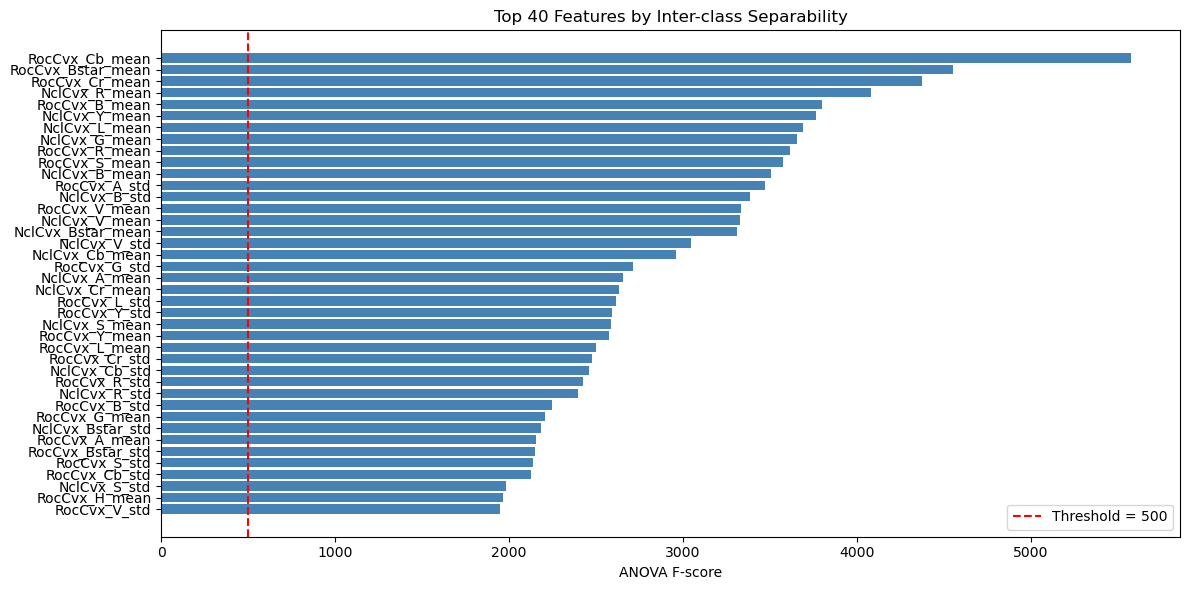

,feature,f_score,p_value
0,RocCvx_Cb_mean,5579.936476,0.0
1,RocCvx_Bstar_mean,4551.831747,0.0
2,RocCvx_Cr_mean,4375.054701,0.0
3,NclCvx_R_mean,4082.839218,0.0
4,RocCvx_B_mean,3798.439609,0.0
5,NclCvx_Y_mean,3763.169637,0.0
6,NclCvx_L_mean,3689.645987,0.0
7,NclCvx_G_mean,3656.869346,0.0
8,RocCvx_R_mean,3617.707168,0.0
9,RocCvx_S_mean,3575.195968,0.0


In [ ]:
f_scores, p_values = f_classif(X[feature_cols], y)
# f_classif is for multi-class — uses ANOVA F-score
#https://scikit-learn.org/stable/modules/feature_selection.html#univariate-feature-selection
importance_df = pd.DataFrame({
    'feature' : feature_cols,
    'f_score' : f_scores,
    'p_value' : p_values
}).sort_values('f_score', ascending=False).reset_index(drop=True)

print(f'Features with F-score >= {FTEST_MIN_SCORE}: '
      f'{(importance_df.f_score >= FTEST_MIN_SCORE).sum()}')
print(f'Features with p_value > 0.05             : '
      f'{(importance_df.p_value > 0.05).sum()}')

# Plot top-40 F-scores
top40 = importance_df.head(40)
plt.figure(figsize=(12, 6))
colors = ['steelblue' if s >= FTEST_MIN_SCORE else 'salmon'
          for s in top40.f_score]
plt.barh(top40.feature[::-1], top40.f_score[::-1], color=colors[::-1])
plt.axvline(FTEST_MIN_SCORE, color='red', linestyle='--',
            label=f'Threshold = {FTEST_MIN_SCORE}')
plt.xlabel('ANOVA F-score')
plt.title('Top 40 Features by Inter-class Separability')
plt.legend()
plt.tight_layout()
plt.show()

display(importance_df)

## 5. Remove Highly Correlated Features

Among each correlated pair (|r| ≥ threshold), drop the one with the **lower F-score**.  
Shape features are always protected from being dropped.

In [50]:
f_lookup = importance_df.set_index('feature')['f_score']
corr_matrix = X[feature_cols].corr().abs()

to_drop = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        feat_i = corr_matrix.columns[i]
        feat_j = corr_matrix.columns[j]

        if corr_matrix.iloc[i, j] >= CORR_THRESHOLD:
            # Never drop shape features
            if feat_i in SHAPE_FEATURES or feat_j in SHAPE_FEATURES:
                continue
            score_i = f_lookup.get(feat_i, 0)
            score_j = f_lookup.get(feat_j, 0)
            loser   = feat_i if score_i < score_j else feat_j
            to_drop.add(loser)

print(f'Features to drop (|r| >= {CORR_THRESHOLD}): {len(to_drop)}')
print(sorted(to_drop))

# ── Greedy-order safety check ──────────────────────────────────────
print('\n── Greedy safety check ──')
remaining_after_drop = [f for f in feature_cols if f not in to_drop]
override = []
for feat in list(to_drop):
    for kept in remaining_after_drop:
        if kept in corr_matrix.columns and feat in corr_matrix.columns:
            if corr_matrix.loc[feat, kept] >= CORR_THRESHOLD:
                if f_lookup.get(feat, 0) > f_lookup.get(kept, 0):
                    override.append((feat, kept,
                                     f_lookup.get(feat, 0),
                                     f_lookup.get(kept, 0)))

if override:
    print('Greedy order caused wrong drops — applying overrides:')
    for dropped, kept, s_d, s_k in override:
        print(f'   Restoring {dropped} (F={s_d:.0f}) and dropping {kept} (F={s_k:.0f}) instead')
        to_drop.discard(dropped)
        to_drop.add(kept)
else:
    print('No issues detected.')

Features to drop (|r| >= 0.9): 32
['NclCvx_A_mean', 'NclCvx_A_std', 'NclCvx_B_mean', 'NclCvx_Bstar_mean', 'NclCvx_Bstar_std', 'NclCvx_Cb_mean', 'NclCvx_Cb_std', 'NclCvx_G_mean', 'NclCvx_G_std', 'NclCvx_L_mean', 'NclCvx_L_std', 'NclCvx_R_std', 'NclCvx_S_mean', 'NclCvx_S_std', 'NclCvx_V_mean', 'NclCvx_V_std', 'NclCvx_Y_mean', 'NclCvx_Y_std', 'RocCvx_A_mean', 'RocCvx_Bstar_mean', 'RocCvx_Bstar_std', 'RocCvx_Cb_std', 'RocCvx_G_mean', 'RocCvx_L_mean', 'RocCvx_L_std', 'RocCvx_R_std', 'RocCvx_S_mean', 'RocCvx_S_std', 'RocCvx_V_mean', 'RocCvx_V_std', 'RocCvx_Y_mean', 'RocCvx_Y_std']

── Greedy safety check ──
No issues detected.


## 6. Build Reduced Feature Set

In [51]:
# Start with all features, remove correlated losers and low F-score features
low_f_features = importance_df.loc[
    importance_df.f_score < FTEST_MIN_SCORE, 'feature'
].tolist()
# Never drop shape features even if F-score is low
low_f_features = [f for f in low_f_features if f not in SHAPE_FEATURES]

final_drop = to_drop | set(low_f_features)

reduced_features = [f for f in feature_cols if f not in final_drop]

print(f'Dropped for high correlation : {len(to_drop)}')
print(f'Dropped for low F-score      : {len(low_f_features)}')
print(f'Total features dropped       : {len(final_drop)}')
print(f'Remaining features           : {len(reduced_features)}')
print(f'\nFinal feature list:')
for f in sorted(reduced_features):
    print(f'  {f}  (F={f_lookup.get(f, 0):.1f})')

Dropped for high correlation : 32
Dropped for low F-score      : 0
Total features dropped       : 32
Remaining features           : 19

Final feature list:
  Circularity  (F=738.7)
  Convexity  (F=1716.1)
  NclCvx_B_std  (F=3383.8)
  NclCvx_Cr_mean  (F=2632.7)
  NclCvx_Cr_std  (F=1007.7)
  NclCvx_H_mean  (F=1078.2)
  NclCvx_H_std  (F=1933.6)
  NclCvx_R_mean  (F=4082.8)
  RocCvx_A_std  (F=3471.8)
  RocCvx_B_mean  (F=3798.4)
  RocCvx_B_std  (F=2249.4)
  RocCvx_Cb_mean  (F=5579.9)
  RocCvx_Cr_mean  (F=4375.1)
  RocCvx_Cr_std  (F=2474.9)
  RocCvx_G_std  (F=2715.4)
  RocCvx_H_mean  (F=1964.3)
  RocCvx_H_std  (F=768.5)
  RocCvx_R_mean  (F=3617.7)
  Solidity  (F=1317.2)


## 7. Criterion 4 — SVM Benchmark

Compare cross-validated SVM accuracy: **all features** vs **reduced features**.

In [55]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.svm             import SVC
feature_cols = FEATURE_COLS
X = df[feature_cols + ['augmented']].copy()
y_raw = df[LABEL_COL].copy()

le = LabelEncoder()
# Wrap the result back into a Series to restore the index
y = pd.Series(le.fit_transform(y_raw), index=y_raw.index, name=LABEL_COL)
# ── 1. Define hold-out test set ─────────────────────────────────────────────
# Only untouched originals (augmented == 0) are eligible for testing
pristine_mask = X["augmented"] == 0
X_pristine    = X[pristine_mask]
y_pristine    = y[pristine_mask]

# 20 % of pristine originals → held-out test set, stratified by class
X_pristine_train, X_test, y_pristine_train, y_test = train_test_split(
    X_pristine, y_pristine,
    test_size=0.20,
    stratify=y_pristine,
    random_state=42
)

# ── 2. Build the training pool ───────────────────────────────────────────────
# augmented == 1  →  originals that were used as rotation sources
# augmented == 2  →  the rotated copies themselves
# + the 80 % of pristine originals not reserved for testing
non_pristine_mask = X["augmented"] != 0
X_train = pd.concat([X[non_pristine_mask], X_pristine_train])
y_train = pd.concat([y[non_pristine_mask], y_pristine_train])

print(f"Train pool : {len(X_train):,} samples  "
      f"(aug=1: {(X_train['augmented']==1).sum():,} | "
      f"aug=2: {(X_train['augmented']==2).sum():,} | "
      f"aug=0 kept: {(X_train['augmented']==0).sum():,})")
print(f"Test set   : {len(X_test):,} samples  (aug=0 only — no leakage)\n")

# ── 3. Cross-validate on the training pool ───────────────────────────────────
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='rbf', C=10, gamma='scale', random_state=42))
])

print(f'Running {CV_FOLDS}-fold CV on training pool ...')
scores_all = cross_val_score(
    svm_pipeline, X_train[feature_cols], y_train,
    cv=cv, scoring='accuracy', n_jobs=-1
)
scores_reduced = cross_val_score(
    svm_pipeline, X_train[reduced_features], y_train,
    cv=cv, scoring='accuracy', n_jobs=-1
)

print(f'\nAll features     ({len(feature_cols):2d}): '
      f'{scores_all.mean():.4f} ± {scores_all.std():.4f}')
print(f'Reduced features ({len(reduced_features):2d}): '
      f'{scores_reduced.mean():.4f} ± {scores_reduced.std():.4f}')

delta = scores_reduced.mean() - scores_all.mean()
print(f'\nCV accuracy delta: {delta:+.4f}')
if delta >= -0.012:
    print('  Reduced set retains performance — safe to proceed.')
else:
    print('  Accuracy drop > 1.2 % — consider relaxing CORR_THRESHOLD or FTEST_MIN_SCORE.')

# ── 4. Final hold-out evaluation ─────────────────────────────────────────────
print('\n── Hold-out Test Set Evaluation (aug=0 only) ──')
for label, cols in [('All features    ', feature_cols),
                     ('Reduced features', reduced_features)]:
    svm_pipeline.fit(X_train[cols], y_train)
    test_acc = svm_pipeline.score(X_test[cols], y_test)
    print(f'  {label} ({len(cols):2d}): {test_acc:.4f}')

Train pool : 25,816 samples  (aug=1: 6,234 | aug=2: 10,902 | aug=0 kept: 8,680)
Test set   : 2,171 samples  (aug=0 only — no leakage)

Running 5-fold CV on training pool ...

All features     (51): 0.9428 ± 0.0005
Reduced features (19): 0.9314 ± 0.0029

CV accuracy delta: -0.0115
  Reduced set retains performance — safe to proceed.

── Hold-out Test Set Evaluation (aug=0 only) ──
  All features     (51): 0.9387
  Reduced features (19): 0.9332


## 8. Summary Report

,Stage,N Features
0,Original,51
1,After corr. drop,19
2,After F-score filter,19
3,Final reduced,19


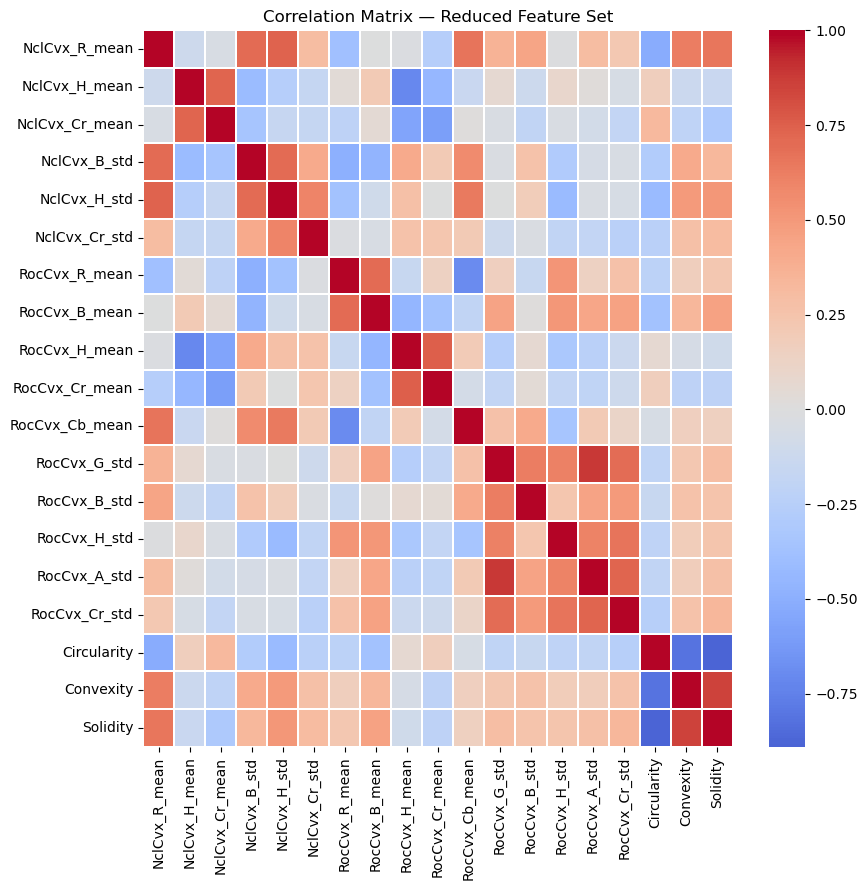

In [56]:
summary = pd.DataFrame({
    'Stage'   : ['Original', 'After corr. drop', 'After F-score filter', 'Final reduced'],
    'N Features': [
        len(feature_cols),
        len(feature_cols) - len(to_drop),
        len(feature_cols) - len(to_drop) - len(low_f_features),
        len(reduced_features)
    ]
})
display(summary)

# Heatmap of reduced feature correlations
plt.figure(figsize=(max(8, len(reduced_features)//2),
                    max(6, len(reduced_features)//2)))
sns.heatmap(X[reduced_features].corr(), cmap='coolwarm', center=0,
            annot=False,
            fmt='.2f', linewidths=0.3)
plt.title('Correlation Matrix — Reduced Feature Set')
plt.tight_layout()
plt.show()

## 9. Export reduced_features.csv

In [57]:
output_df = df[['Filepath','Source','augmented']+ reduced_features + [LABEL_COL]]
output_df.to_csv(OUTPUT_PATH, index=False)

print(f'✅ Saved → {OUTPUT_PATH}')
print(f'   Shape : {output_df.shape}')
print(f'   Features exported:')
for f in sorted(reduced_features):
    print(f'     {f}')

✅ Saved → reduced_features.csv
   Shape : (27987, 23)
   Features exported:
     Circularity
     Convexity
     NclCvx_B_std
     NclCvx_Cr_mean
     NclCvx_Cr_std
     NclCvx_H_mean
     NclCvx_H_std
     NclCvx_R_mean
     RocCvx_A_std
     RocCvx_B_mean
     RocCvx_B_std
     RocCvx_Cb_mean
     RocCvx_Cr_mean
     RocCvx_Cr_std
     RocCvx_G_std
     RocCvx_H_mean
     RocCvx_H_std
     RocCvx_R_mean
     Solidity


In [59]:
output_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27987 entries, 0 to 27986
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Filepath        27987 non-null  object 
 1   Source          27987 non-null  object 
 2   augmented       27987 non-null  int64  
 3   NclCvx_R_mean   27987 non-null  float64
 4   NclCvx_H_mean   27987 non-null  float64
 5   NclCvx_Cr_mean  27987 non-null  float64
 6   NclCvx_B_std    27987 non-null  float64
 7   NclCvx_H_std    27987 non-null  float64
 8   NclCvx_Cr_std   27987 non-null  float64
 9   RocCvx_R_mean   27987 non-null  float64
 10  RocCvx_B_mean   27987 non-null  float64
 11  RocCvx_H_mean   27987 non-null  float64
 12  RocCvx_Cr_mean  27987 non-null  float64
 13  RocCvx_Cb_mean  27987 non-null  float64
 14  RocCvx_G_std    27987 non-null  float64
 15  RocCvx_B_std    27987 non-null  float64
 16  RocCvx_H_std    27987 non-null  float64
 17  RocCvx_A_std    27987 non-null 